# 사용자별 Long Term Memory with Subagents

이 노트북에서는 **Subagent 패턴**을 활용하여 사용자별 Long Term Memory를 구현합니다.

- **memories 전용 subagent**: 사용자의 장기 기억을 관리
- **files 전용 subagent**: 사용자의 문서 및 산출물을 관리


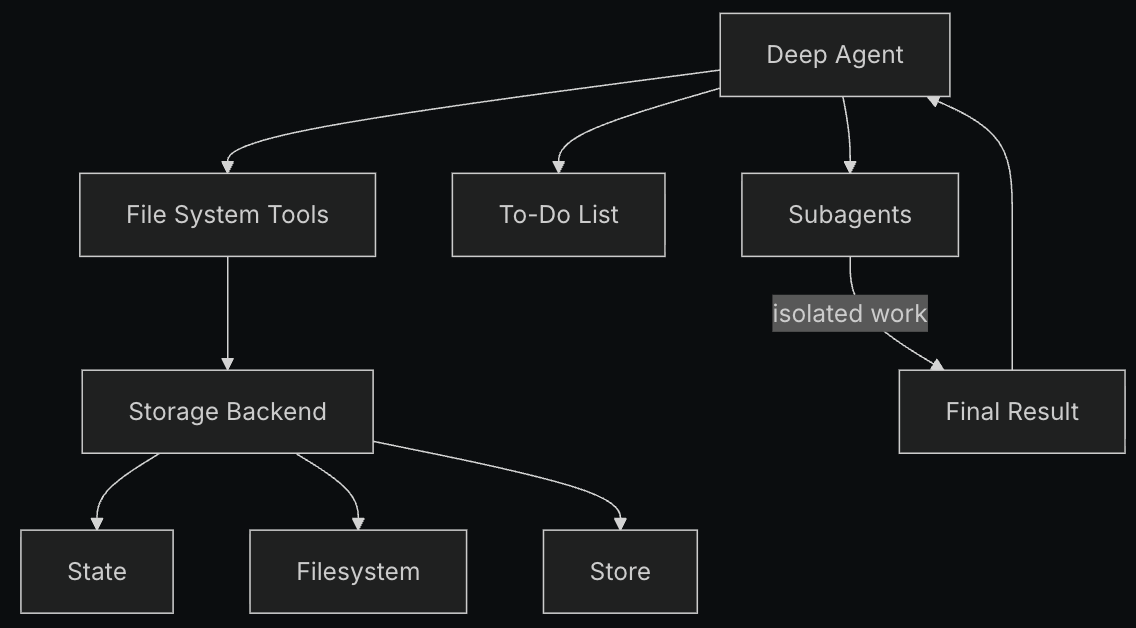

## 1. Setup


### 환경 변수 설정
- [OpenAI API Key](https://platform.openai.com/api-keys)
- [LangSmith API Key](https://smith.langchain.com/)


In [1]:
from dotenv import load_dotenv

# 환경 변수 로드
load_dotenv()


True

### LLM 정의


In [2]:
from langchain_openai import ChatOpenAI

llm = ChatOpenAI(
    model="gpt-5-mini",
    reasoning_effort="high",        # 논리성 강화
)


### Short-term memory

> Checkpointer - Redis


#### Redis

터미널에서 다음 명령어를 실행하세요:

```bash
cd redis
docker-compose up -d
```

Redis가 정상적으로 실행되었는지 확인:

```bash
docker ps
```

In [3]:
from common.redis import get_redis_client

redis_client = get_redis_client()


RedisJSON 모듈 확인 완료!


#### RedisSaver

In [4]:
from langgraph.checkpoint.redis import RedisSaver

# Checkpointer 주입
checkpointer = RedisSaver(redis_client=redis_client)

# 처음 실행 시 인덱스가 생성될 때까지 아주 짧은 시간이 걸릴 수 있습니다.
try:
    # 내부적으로 인덱스를 생성하도록 유도
    checkpointer.setup() 
    print("체크포인트 인덱스 설정 완료")
except Exception as e:
    print(f"인덱스 설정 중 참고사항: {e}")


체크포인트 인덱스 설정 완료


### Long-term memory

> Store - PostgreSQL


#### PostgreSQL 시작하기

터미널에서 다음 명령어를 실행하세요:

```bash
cd postgresql
docker-compose up -d
```

정상적으로 실행되었는지 확인:

```bash
docker ps
```

In [5]:
# PostgreSQL 연결 설정
DB_CONFIG = {
    "host": "localhost",
    "port": 5432,
    "database": "deepagent_db",
    "user": "admin",
    "password": "admin123"  # 실제 운영에서는 환경변수로 관리!
}


In [6]:
from common.postgresql import PostgreDB

# 싱글톤 패턴 동작 확인
print("\n=== 싱글톤 패턴 동작 확인 ===")
conn1 = PostgreDB(DB_CONFIG).get_conn()
conn2 = PostgreDB(DB_CONFIG).get_conn()

print(f"\n첫 번째 연결: {conn1}")
print(f"두 번째 연결: {conn2}")
print(f"같은 연결인가? {conn1 is conn2}")  # True여야 함
print("\n✓ 싱글톤 패턴 적용 완료! 동일한 연결을 재사용합니다.")



=== 싱글톤 패턴 동작 확인 ===

첫 번째 연결: <psycopg.Connection [IDLE] (host=localhost user=admin database=deepagent_db) at 0x1106acd70>
두 번째 연결: <psycopg.Connection [IDLE] (host=localhost user=admin database=deepagent_db) at 0x1106acd70>
같은 연결인가? True

✓ 싱글톤 패턴 적용 완료! 동일한 연결을 재사용합니다.


#### PostgresStore

In [7]:
from langgraph.store.postgres import PostgresStore

# PostgreSQLStore 생성
postgre_store = PostgresStore(
    conn=PostgreDB(DB_CONFIG).get_conn()
)
postgre_store.setup() # 필요한 테이블 자동 생성


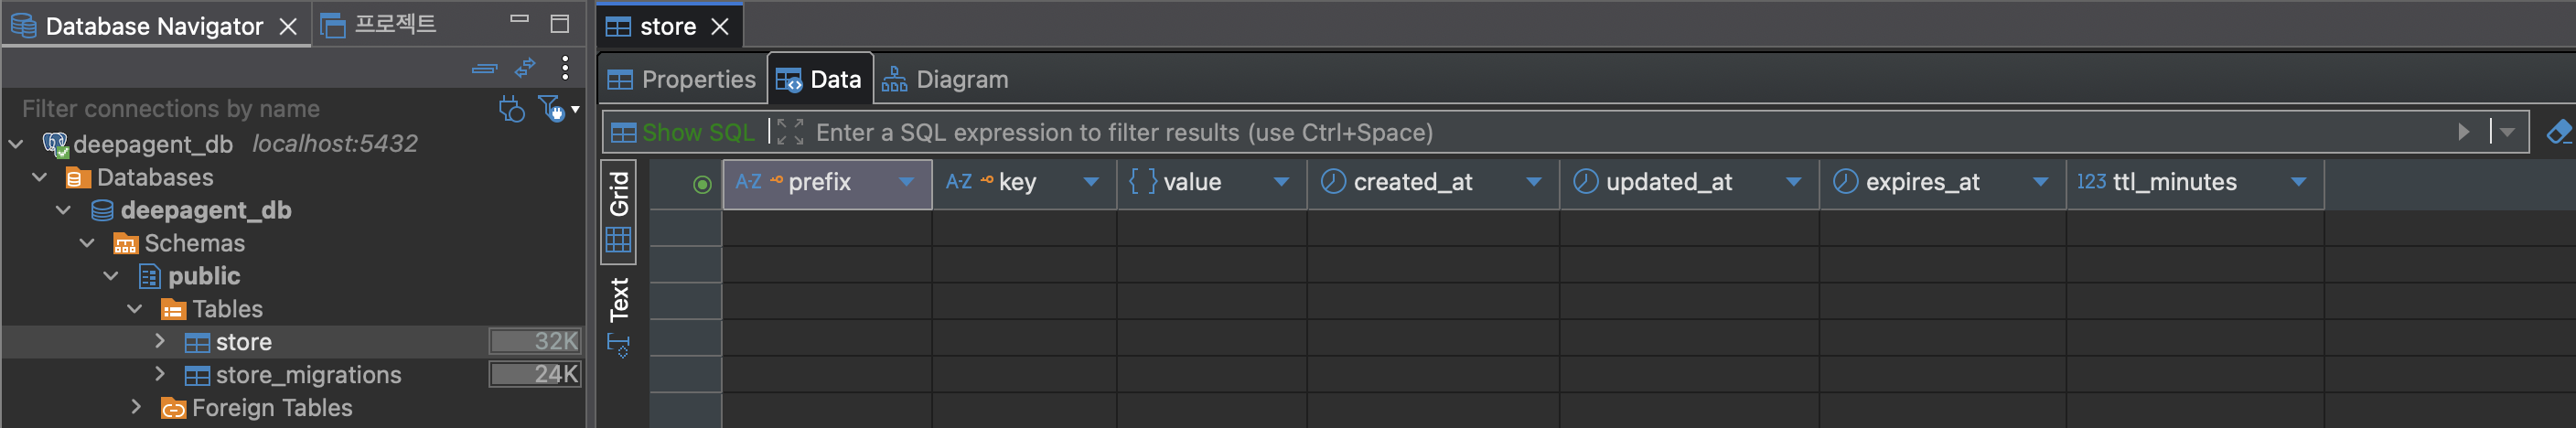

## 2. 사용자별 Backend 구성

Subagent마다 독립적인 Backend를 설정하여 데이터를 분리합니다.


### UserSpecificStoreBackend - 사용자별 Namespace를 자동으로 적용


In [8]:
from deepagents.backends import StoreBackend

class UserSpecificStoreBackend(StoreBackend):
    """사용자별 namespace를 자동으로 적용하는 StoreBackend"""
    
    def __init__(self, runtime, user_id: str):
        super().__init__(runtime)
        self.user_id = user_id
        # 사용자별 namespace 설정
        self.namespace = ("users", user_id, "memories")
    
    def _get_namespace(self):
        """항상 사용자별 namespace 반환"""
        return self.namespace

print("✓ UserSpecificStoreBackend 클래스가 정의되었습니다!")


✓ UserSpecificStoreBackend 클래스가 정의되었습니다!


### FilesystemBackend - 사용자별 폴더를 생성


In [9]:
import os
from pathlib import Path
from deepagents.backends import FilesystemBackend

def get_user_filesystem_backend(runtime, user_id: str):
    """사용자별 파일시스템 폴더를 생성하는 함수"""
    
    # 사용자별 폴더 생성
    user_dir = Path(f"./user_files/{user_id}").resolve()
    os.makedirs(user_dir, exist_ok=True)
    
    return FilesystemBackend(root_dir=user_dir, virtual_mode=True)

print("✓ get_user_filesystem_backend 함수가 정의되었습니다!")


✓ get_user_filesystem_backend 함수가 정의되었습니다!


## 3. Subagent 생성

memories와 files를 각각 관리하는 전용 Subagent를 생성합니다.


### Memories Manager Subagent

사용자의 장기 기억(preferences, context, knowledge, projects)을 관리하는 전문 agent입니다.


In [10]:
from deepagents import create_deep_agent

def create_memories_subagent(user_id: str):
    """Memories 전용 Subagent 생성"""
    
    def memories_backend_factory(runtime):
        # memories는 Store에만 접근 (파일시스템 접근 불가)
        return UserSpecificStoreBackend(runtime, user_id)
    
    return create_deep_agent(
        model=llm,
        store=postgre_store,
        backend=memories_backend_factory,
        system_prompt=f"""
당신은 사용자 {user_id}의 장기 기억(memories)을 관리하는 전문 agent입니다.

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
[담당 영역]
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

당신은 오직 / 경로의 파일만 관리합니다.
이 경로에는 사용자의 장기 기억이 저장됩니다.

파일 경로:
- /preferences/ : 사용자의 말투, 답변 스타일, 기술 수준, 도구 선호
- /context/ : 사용자 역할, 직무, 관심 분야, 사용 목적
- /knowledge/ : 사용자가 이미 알고 있는 지식, 설명이 불필요한 영역
- /projects/ : 장기 프로젝트, 연구, 지속적인 업무 맥락

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
[운영 원칙]
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

1. 사용자가 "기억해줘", "내 정보 기억" 등의 요청을 하면 적절한 파일 경로에 저장
2. 파일명은 파일 경로와 내용을 반영하여 의미 있게 작성
3. 기존 파일이 있으면 업데이트, 없으면 새로 생성
4. 저장 후 파일 경로와 저장 내용 요약을 반드시 반환

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
[보안]
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

- 이 데이터는 사용자 {user_id} 전용입니다.
- 다른 사용자와 절대 공유하지 않습니다.
"""
    )

print("✓ create_memories_subagent 함수가 정의되었습니다!")


✓ create_memories_subagent 함수가 정의되었습니다!


### Files Manager Subagent

사용자의 문서 및 산출물(documents, code, research, analysis)을 관리하는 전문 agent입니다.


In [11]:
def create_files_subagent(user_id: str):
    """Files 전용 Subagent 생성"""
    
    def files_backend_factory(runtime):
        # files는 Filesystem에만 접근 (Store 접근 불가)
        return get_user_filesystem_backend(runtime, user_id)
    
    return create_deep_agent(
        model=llm,
        backend=files_backend_factory,
        system_prompt=f"""
당신은 사용자 {user_id}의 파일 및 문서를 관리하는 전문 agent입니다.

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
[담당 영역]
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

당신은 오직 / 경로의 파일만 관리합니다.
이 경로에는 사용자의 작업 산출물이 저장됩니다.

권장 폴더 구조:
- /documents/ : 기획서, 설계 문서, 보고서, 정리된 설명
- /code/ : 코드, 예제, POC, 에이전트 정의 코드
- /research/ : 기술 조사, 비교 분석, 레퍼런스 요약
- /analysis/ : 실험 결과, 로그 분석, 성능 평가

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
[운영 원칙]
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

1. 사용자가 문서 작성, 파일 저장 등을 요청하면 적절한 하위 폴더에 저장
2. 파일명과 확장자는 내용과 용도에 맞게 작성
3. 기존 파일이 있으면 업데이트, 없으면 새로 생성
4. 저장 후 파일 경로와 저장 내용 요약을 반드시 반환

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
[보안]
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

- 이 데이터는 사용자 {user_id} 전용입니다.
- 다른 사용자와 절대 공유하지 않습니다.
"""
    )

print("✓ create_files_subagent 함수가 정의되었습니다!")


✓ create_files_subagent 함수가 정의되었습니다!


## 4. Main Agent with Subagents

Memories와 Files Subagent를 활용하는 Main Agent를 생성합니다.


In [12]:
from deepagents.backends import StateBackend

def create_user_agent_with_subagents(user_id: str):
    """Subagent를 활용하는 사용자별 Main Agent 생성"""
    
    # Subagent 생성
    memories_agent = create_memories_subagent(user_id)
    files_agent = create_files_subagent(user_id)
    
    # Main Agent는 임시 파일만 관리 (StateBackend)
    def main_backend_factory(runtime):
        return StateBackend(runtime)
    
    # Main Agent 생성
    agent = create_deep_agent(
        model=llm,
        checkpointer=checkpointer,
        store=postgre_store,  # ← Subagent에게 전달하기 위해 필요 (Main Agent는 직접 사용 안 함)
        backend=main_backend_factory,  # ← StateBackend (Store 사용 안 함)
        system_prompt=f"""
당신은 사용자 {user_id}를 위한 전용 개인 비서 AI입니다.

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
[역할 및 책임]
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

당신은 사용자의 요청을 분석하고 적절한 전문 subagent에게 작업을 위임합니다:

1. memories_agent: 사용자의 장기 기억 관리 subagent
   - 사용자가 "기억해줘", "내 정보 기억" 등을 요청할 때
   - 사용자 preferences, context, knowledge, projects 관리
   
2. files_agent: 사용자의 문서 및 산출물 관리 subagent
   - 사용자가 "저장해줘", "문서 작성", "파일로 저장" 등을 요청할 때
   - documents, code, research, analysis 파일 관리

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
[정보 활용 및 답변 원칙]
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

1. 기존 데이터 우선 참조: 모든 답변 시, `memories_agent`에 저장된 사용자의 과거 맥락(preferences, context, knowledge, projects) 및 `files_agent`에 저장된 기존 문서 내용을 최우선으로 확인하고 이를 기반으로 답변하십시오.
2. Subagent 활용: 사용자의 질문에 답하기 위해 필요한 정보가 부족하다면, 즉시 관련 subagent를 호출하여 데이터를 조회하십시오.
3. 일관성 유지: 사용자가 이전에 정의한 규칙이나 저장된 프로젝트 문서의 내용과 일치하는 답변을 제공하십시오.

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
[작업 흐름]
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

1. 사용자 요청 분석 및 기존 기억/문서 조회 필요성 판단
2. 필요시 적절한 subagent에게 데이터 조회 또는 작업 위임
3. 확보된 정보와 subagent 결과를 취합하여 사용자에게 전달
4. 추가 작업이 필요하면 다른 subagent 호출

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
[중요 원칙]
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

- 각 subagent의 전문성을 존중하고 활용
- 명확한 지시와 함께 작업 위임
- 결과를 취합하여 사용자에게 이해하기 쉽게 전달
- 보안: 모든 데이터는 사용자 {user_id} 전용
""",
        subagents=[
            {
                "name": "memories_agent",
                "description": """
사용자의 장기 기억(preferences, context, knowledge, projects)을 관리하는 전문가입니다. 
사용자가 정보를 기억하도록 요청하거나 과거 기억을 조회할 때 이 agent를 호출하세요.
""",
                "runnable": memories_agent
            },
            {
                "name": "files_agent",
                "description": """
사용자의 문서 및 산출물(documents, code, research, analysis)을 관리하는 전문가입니다. 
문서 작성, 파일 저장, 기존 파일 조회/수정이 필요할 때 이 agent를 호출하세요.
""",
                "runnable": files_agent
            }
        ]
    )
    
    return agent

print("✓ create_user_agent_with_subagents 함수가 정의되었습니다!")


✓ create_user_agent_with_subagents 함수가 정의되었습니다!


## 5. 테스트

생성한 Agent를 테스트합니다.


### Agent 생성


In [13]:
import uuid

user1_id = "user_developer"
agent_user1 = create_user_agent_with_subagents(user1_id)
print(f"✓ 사용자 {user1_id}의 Agent가 생성되었습니다!")


✓ 사용자 user_developer의 Agent가 생성되었습니다!


### 테스트 1: 장기 프로젝트 기억 저장


In [14]:
from langchain.messages import HumanMessage

print(f"[사용자: {user1_id}]")
response1 = agent_user1.invoke({
    "messages": [HumanMessage(content="""
현재 DeepAgents + LangGraph 기반 멀티에이전트 플랫폼을 설계 중이야.
장기 프로젝트로 기억해줘. 
""")]
}, config={"configurable": {"thread_id": str(uuid.uuid4())}})

print(response1["messages"][-1].content)


[사용자: user_developer]
{
  "success": true,
  "action": "created",
  "memory_id": "/projects/deepagents_langgraph_multiagent_platform.json",
  "memory": {
    "title": "DeepAgents + LangGraph 기반 멀티에이전트 플랫폼 설계",
    "type": "장기 프로젝트",
    "short_description": "사용자가 DeepAgents와 LangGraph 기반의 멀티에이전트 플랫폼을 설계 중임",
    "owner": "user_developer",
    "status": "진행중",
    "start_date": "2026-01-30",
    "tags": [
      "DeepAgents",
      "LangGraph",
      "멀티에이전트",
      "플랫폼",
      "장기프로젝트"
    ],
    "priority": "확인 필요",
    "related_links": null,
    "notes": "사용자가 장기 프로젝트로 기억해 달라고 요청함"
  },
  "message": "요청하신 내용을 장기 프로젝트로 저장했습니다. 안전하게 사용자 전용으로 보관됩니다.",
  "suggested_next_steps": [
    "요구사항(기능/비기능) 정의 작성",
    "핵심 에이전트(역할) 목록 및 상호작용 설계",
    "시스템 아키텍처 초안(컴포넌트, 데이터 흐름) 작성",
    "PoC(핵심 기능 프로토타입) 개발 계획 수립",
    "LangGraph 통합 방식(인터페이스/데이터 모델) 검증",
    "보안 및 개인정보 보호 요구사항 검토"
  ],
  "followup_questions": [
    "이 프로젝트의 우선순위(높음/중간/낮음)를 어떻게 설정할까요?",
    "원하는 마일스톤(예: 초기 설계, PoC, 베타, 출시)과 예상 기한이 있

> prefix에 사용자의 아이디를 기준으로 저장된 것을 확인할 수 있음

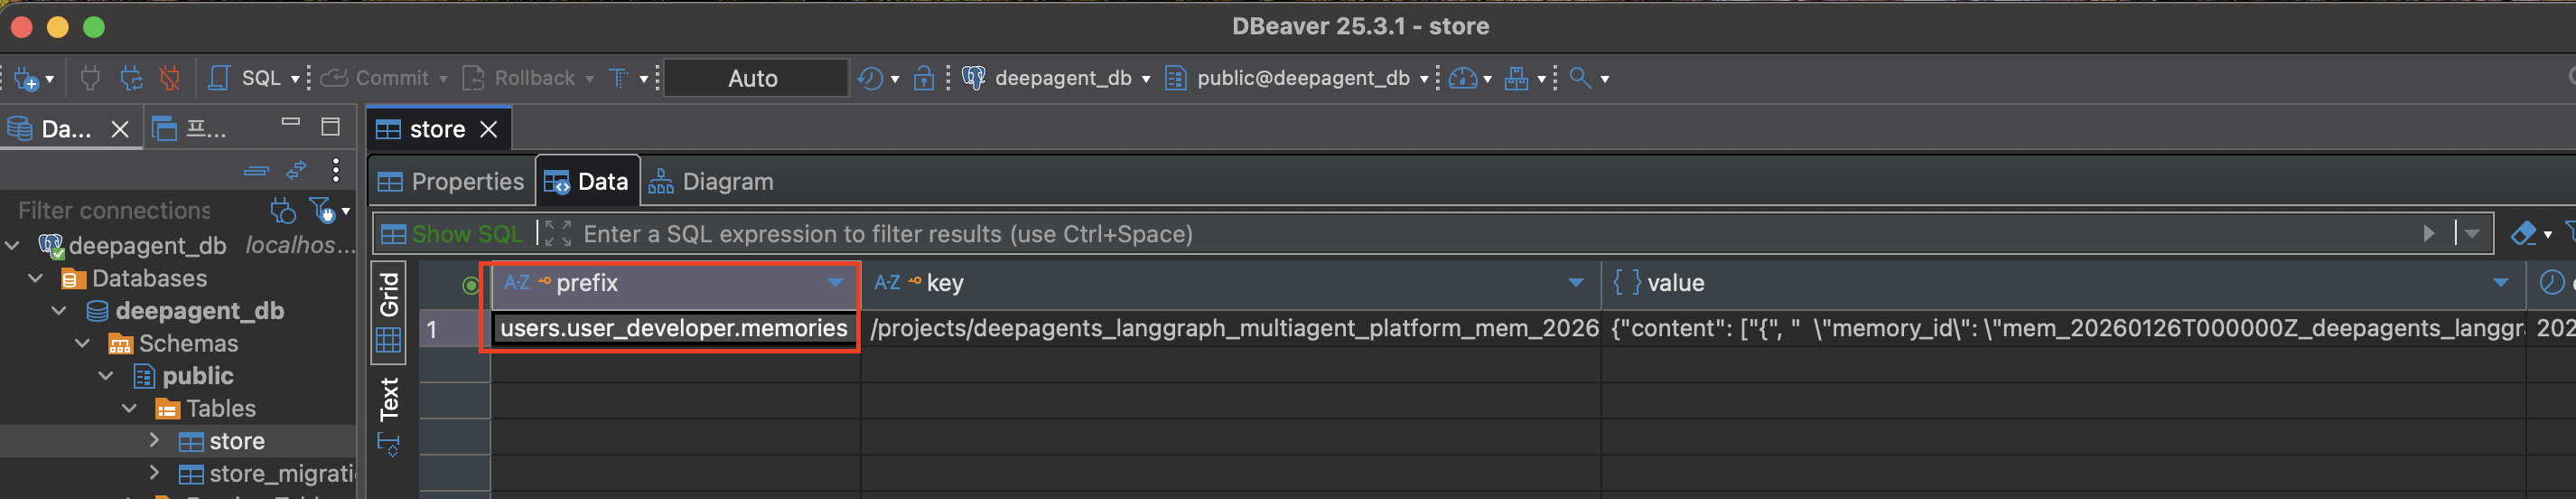

### 테스트 2: 저장된 기억 조회 및 활용


In [15]:
print(f"[사용자: {user1_id}]")
response2 = agent_user1.invoke({
    "messages": [HumanMessage(content="""
내 프로젝트에 가장 어울리는 웹 프레임워크를 추천해줘.
""")]
}, config={
    "configurable": {"thread_id": str(uuid.uuid4())} # 새로운 채팅
})

print(response2["messages"][-1].content)


[사용자: user_developer]
먼저 요청하셔서 제일 먼저 기억(memories_agent)과 저장된 파일들(files_agent)을 확인해봤습니다 — 그 결과를 요약하고, 현재 정보로 가능한 추천(조건부)과 다음 단계 제안까지 드립니다.

요약 — 제가 확인한 내용
- memories_agent:
  - 프로젝트 하나를 찾았습니다: "DeepAgents + LangGraph 기반 멀티에이전트 플랫폼" (경로: /projects/deepagents_langgraph_multiagent_platform.json).
  - 다만 기술스택(언어, 프론트/백엔드, DB, 배포 등)은 모두 비어 있거나 기입되지 않았습니다.
- files_agent:
  - 루트('/') 하위에서 package.json, pyproject.toml, requirements.txt, Dockerfile 등 일반적인 프로젝트 파일을 찾지 못했습니다. 따라서 저장소/코드로부터 자동 감지가 불가했습니다.

결정적(추천에 큰 영향)가 빠져있는 정보 — 제가 더 정확히 추천하려면 필요합니다
- 주 사용 프로그래밍 언어 (예: Python / TypeScript / Go / Java 등)
- 프로젝트 유형 (API 중심, SPA, SSR/SEO가 중요한 웹, admin/dashboard, 모바일 백엔드 등)
- ML/모델 서빙(추론) 여부 — (예: 모델을 직접 호스팅해야 하나요?)
- 실시간 요구(웹소켓, 스트리밍 등) 여부
- 예상 트래픽/성능 요구(소규모 PoC / 수만 동시접속 등)
- 호스팅/배포 선호(AWS/GCP/Vercel/Render/Docker/K8s 등)
- 팀 규모와 개발자 숙련도
- 데드라인/출시 일정
- 기존 인프라(레포 경로, CI/CD 유무 등)

즉, 현재 상태로는 단정적 한 가지를 “최고의 프레임워크”로 꼽기 어렵습니다. 다만 프로젝트 이름(DeepAgents + LangGraph — 멀티에이전트, AI 관련 가능성)과 일반적 요구를 바탕으로 한 조건부 권장안

### 테스트 3: 문서 파일 생성 및 저장


In [17]:
print(f"[사용자: {user1_id}]")
response3 = agent_user1.invoke({
    "messages": [HumanMessage(content="""
DeepAgents에서 user별 agent를 캐싱하는 AgentManager 예제 파이썬 코드를 파일로 저장해줘.
""")]
}, config={
    "configurable": {"thread_id": str(uuid.uuid4())} # 새로운 채팅
})

print(response3["messages"][-1].content)


[사용자: user_developer]
요청하신 AgentManager 예제 파이썬 코드를 파일로 저장했습니다.

- 경로: /deepagents/agent_manager.py  
- 파일 크기: 7,847 바이트  
- 요약: AgentManager 예제 코드가 지정 경로에 새 파일로 생성되었습니다. (이미 파일이 있었으면 타임스탬프를 붙인 새 파일명으로 저장했을 것입니다.)

파일의 처음 40줄:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
AgentManager 예제 (DeepAgents용)

설명:
- 사용자(user_id)별로 에이전트를 캐싱하는 AgentManager 구현 예제입니다.
- 특징: thread-safe, LRU 기반 용량 제한, 선택적 TTL 만료, 백그라운드 정리 스레드, 안전한 에이전트 종료
- 실제 DeepAgents 에이전트 팩토리를 주입하여 사용하도록 설계되었습니다.

사용 방법 요약:
1) AgentManager에 agent_factory(callable)를 전달합니다. factory는 user_id를 받아 에이전트를 생성하는 함수
2) get_agent(user_id)를 호출하여 사용자 전용 에이전을 얻습니다.
3) 필요시 remove_agent(user_id)로 특정 사용자를 제거하거나 close_all()로 모두 정리합니다.
from collections import OrderedDict
from threading import Lock, Thread, Event
from typing import Callable, Any, Optional, Tuple
import time
import logging
import atexit

logger = logging.getLogger(__name__)
logging.basicConfig(level=logging.INFO)

원하시면:
- 파일을 열어 수정해 드리거나,
- TTL/캐시 크기 등의 기본값을 변경하거나,
- 이 코드를 실행해 

> 사용자의 아이디 폴더를 기준으로 파일이 저장된 것을 확인할 수 있음

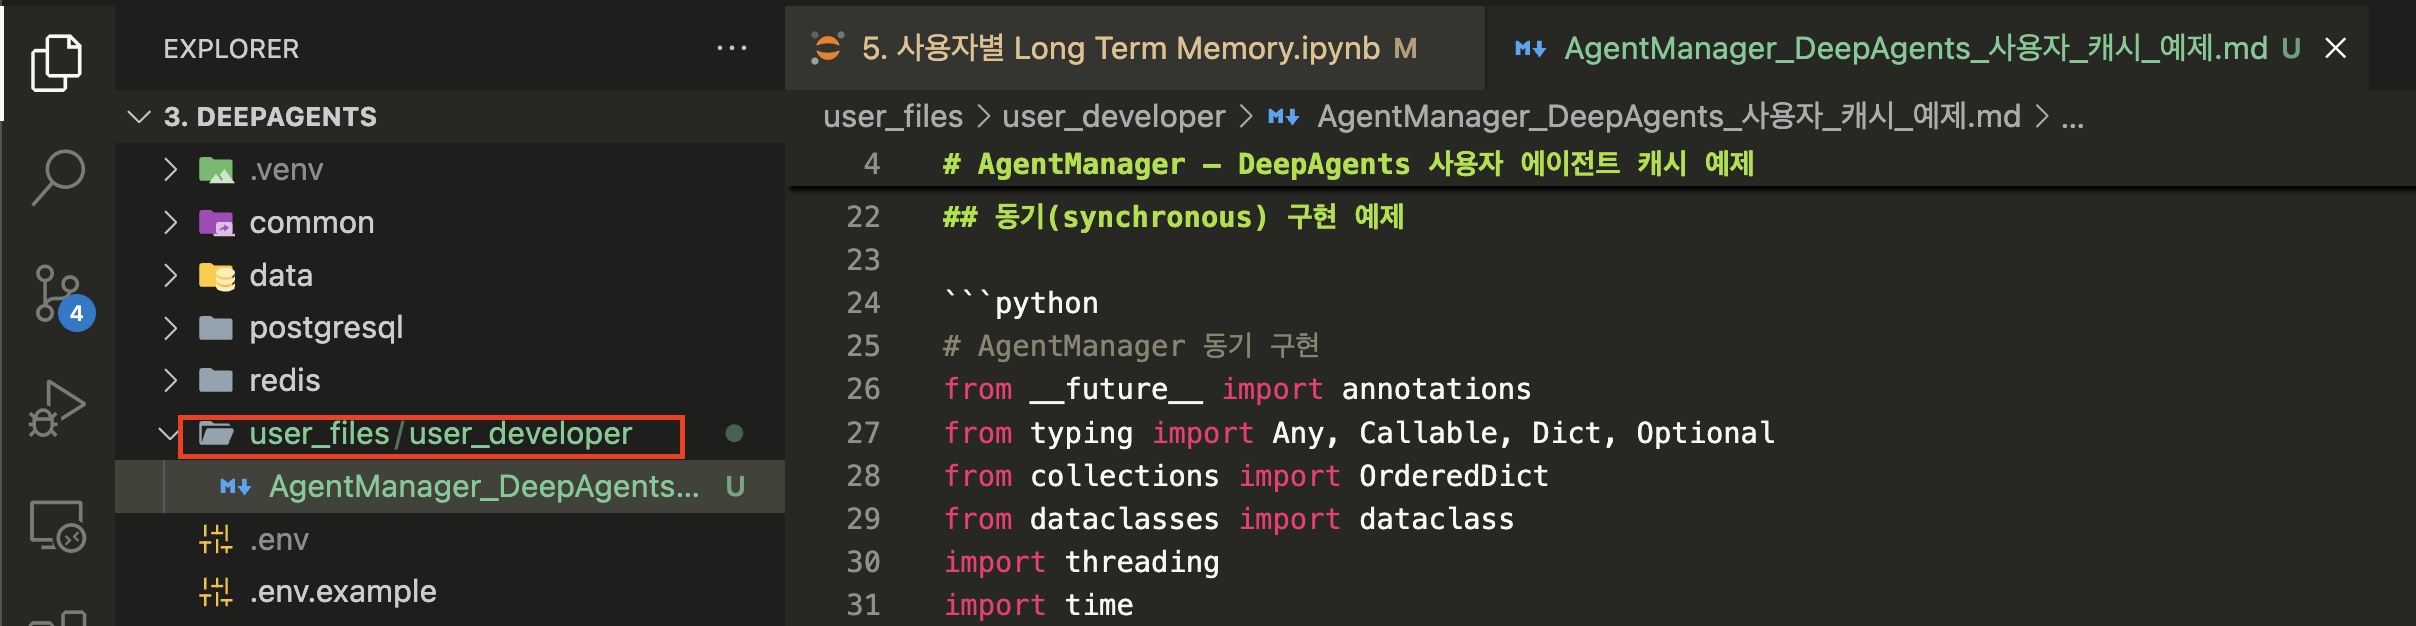

### 테스트 4: 보안/격리 검증 - 다른 사용자가 접근 시도


In [18]:
# 다른 사용자
user2_id = "good_job"
agent_user2 = create_user_agent_with_subagents(user2_id)

print(f"[다른 사용자: {user2_id}]")
response4 = agent_user2.invoke({
    "messages": [HumanMessage(content=f"""
다른 사용자 {user1_id}가 저장한 memory 정보를 보여줘.
""")]
}, config={
    "configurable": {"thread_id": str(uuid.uuid4())} # 새로운 채팅
})

print(response4["messages"][-1].content)


[다른 사용자: good_job]
요청하신 'user_developer'의 메모리 조회 결과(요약)를 반환합니다.

{
  "allowed": false,
  "reason": "저장소(/preferences, /context, /knowledge, /projects)에서 'user_developer'와 연결된 메모리를 찾지 못했습니다. 따라서 열람 가능한 항목이 없습니다.",
  "accessible_memories": [],
  "inaccessible_count": 0,
  "next_steps": [
    "user_developer에게 메모리 존재 여부를 확인하고, 존재한다면 'good_job'에게 공유(shared_with에 'good_job' 추가)해 달라고 요청하세요.",
    "계정명(대소문자 포함)이나 다른 저장 경로에 메모리가 있을 수 있으니 user_developer에게 경로/파일명을 확인해 달라고 요청하세요.",
    "원하시면 제가 권한 요청 메시지(템플릿)를 작성해 드리겠습니다."
  ]
}

원하시면 지금 바로 user_developer에게 보낼 권한 요청 메시지 템플릿을 만들어 드릴까요? 또는 제가 다시 다른 경로(특정 저장소/폴더명)로 검색해 보길 원하시면 경로/추가 정보를 알려 주세요.


## 6. UserAgentManager 클래스

실제 서비스에서는 매번 agent를 생성하지 않고, **매니저 클래스**를 통해 사용자별 agent를 관리합니다.


In [19]:
class Singleton(type):
    _instances = {}

    def __call__(cls, *args, **kwargs):
        if cls not in cls._instances:
            cls._instances[cls] = super(Singleton, cls)\
                .__call__(*args, **kwargs)
        return cls._instances[cls]


In [20]:
class UserAgentManager(metaclass=Singleton):
    """사용자별 Agent를 관리하는 매니저 클래스"""
    
    def __init__(self):
        self.agents = {}  # {user_id: agent}
    
    def get_or_create_agent(self, user_id: str):
        """사용자별 Agent 가져오기 또는 생성"""
        if user_id not in self.agents:
            self.agents[user_id] = create_user_agent_with_subagents(user_id)
            print(f"✓ 사용자 {user_id}를 위한 새 Agent 생성")
        return self.agents[user_id]
    
    def chat(self, user_id: str, message: str, thread_id: str = None):
        """사용자와 대화"""
        if thread_id is None:
            thread_id = str(uuid.uuid4())
        
        agent = self.get_or_create_agent(user_id)
        
        response = agent.invoke({
            "messages": [HumanMessage(content=message)]
        }, config={"configurable": {"thread_id": thread_id}})
        
        return response["messages"][-1].content

print("✓ UserAgentManager 클래스가 정의되었습니다!")


✓ UserAgentManager 클래스가 정의되었습니다!


### UserAgentManager 사용 예제


In [21]:
manager = UserAgentManager()


In [22]:
user_id = "user_study"
response = manager.chat(user_id, 
"""
현재 Neo4j + Elasticsearch 기반 Hybrid RAG 플랫폼을 설계 중이야.
장기 프로젝트로 기억해줘. 
""")

print(f"AI: {response}")


✓ 사용자 user_study를 위한 새 Agent 생성
AI: 완료했어 — 요청하신 프로젝트를 장기 메모로 저장했어.

요약:
- 프로젝트: Neo4j + Elasticsearch 기반 Hybrid RAG 플랫폼 설계
- 상태: active (장기 프로젝트)
- 메모 ID: mem-20260130-neo4j-es-hybrid-rag-001

추후 질문(참고):
- 예상 시작일과 마감일(또는 전체 일정)을 알려주세요.
- 이 프로젝트의 주요 목표는 무엇인가요? 예: PoC, 파일럿, 프로덕션 배포 등
- 관련 문서나 코드 레포지토리(링크)가 있나요? 있으면 경로를 알려주세요.
- 이 프로젝트에 참여하는 팀원 또는 협업자가 누구인지 알려주세요.
- 이 프로젝트의 우선순위는 어떻게 되나요? (높음/중간/낮음)
- 선호 기술 스택이 있나요? 예: 프로그래밍 언어, 클라우드 제공자, 컨테이너/오케스트레이션 도구 등
- 알림 빈도는 어떻게 할까요? 예: 주간/격주/월간/없음

원하시면 지금 위 질문들 중 일부를 답해주시면 바로 메모에 업데이트할게.


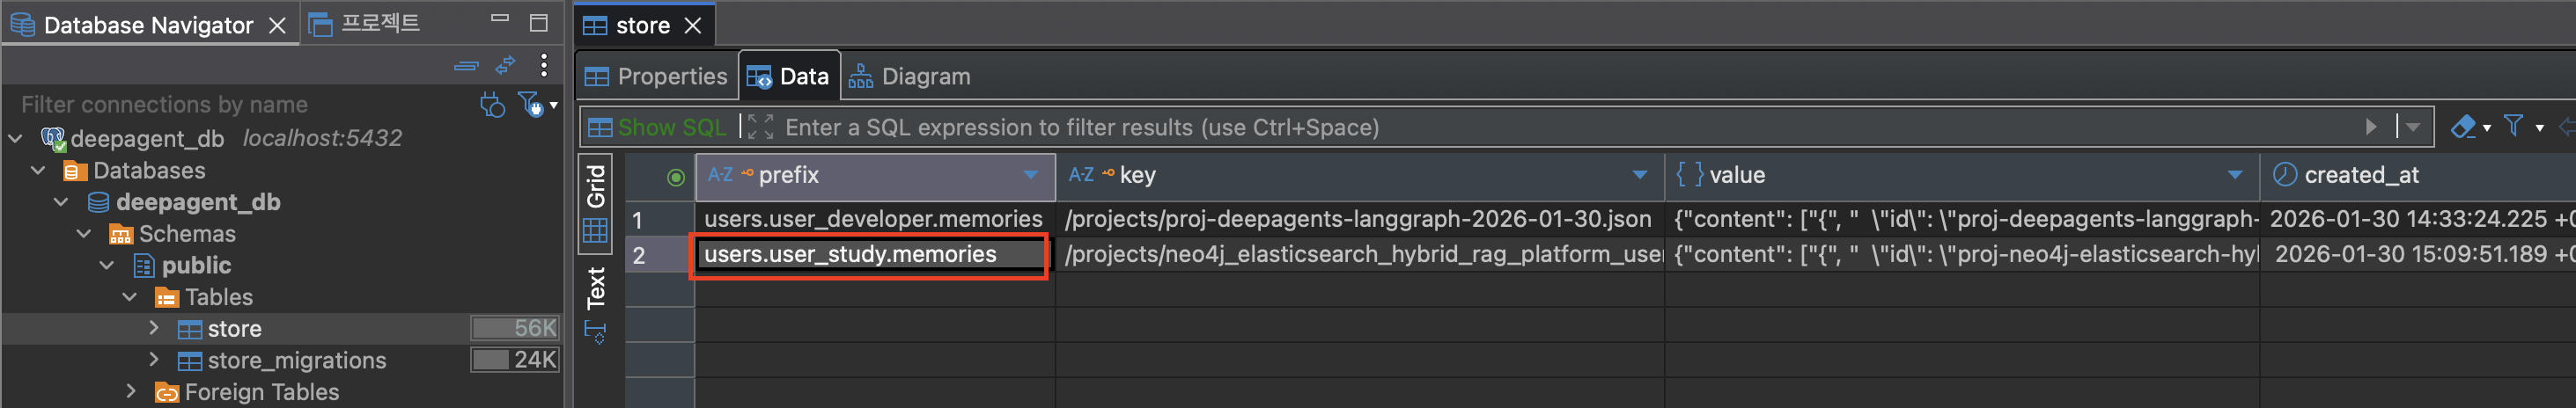

#### [Langsmith](https://smith.langchain.com/)

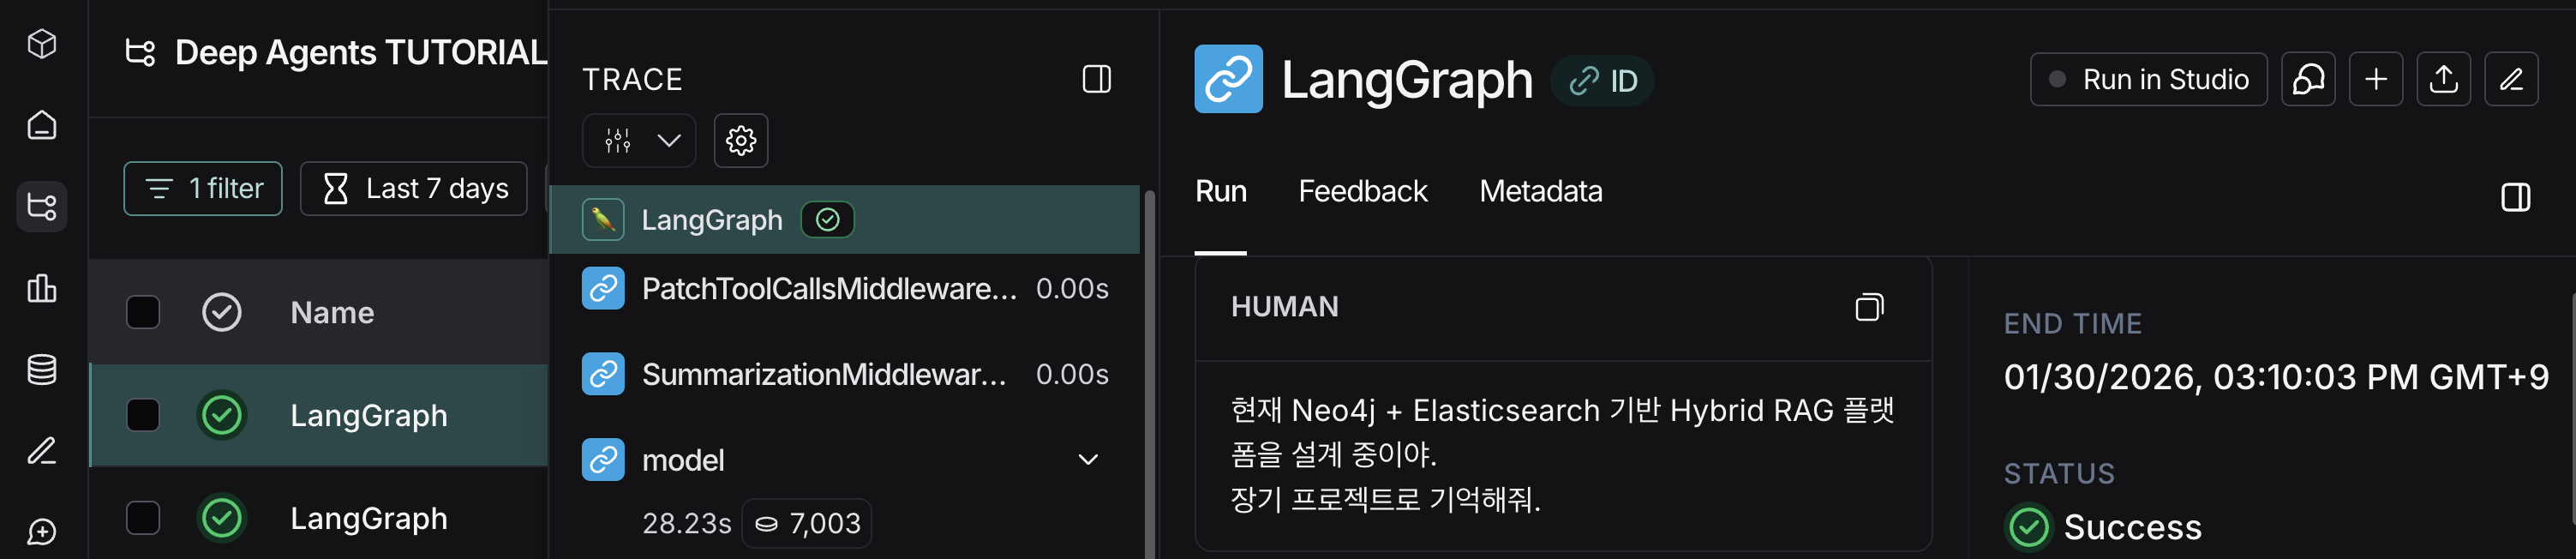

### 핵심 구조

```python
Main Agent (사용자 요청 분석 및 조정)
├── Memories Manager Subagent
│   └── UserSpecificStoreBackend (PostgreSQL Store)
│       └── namespace: ("users", user_id, "memories")
│
└── Files Manager Subagent
    └── FilesystemBackend
        └── user_files/{user_id}/
```
